In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [39]:
words = open('names.txt', 'r').read().splitlines()
# words = open('turkish_names.txt', mode='r', encoding='utf-8').read().splitlines()

In [40]:
chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i,s in enumerate(chars) }
stoi['.'] = 0
itos = { i:s for s,i in stoi.items() }
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [41]:
block_size = 3

def build_data(words):
    X, Y = [], []

    for w in words:
        context = block_size * [0]
        for ch in w + '.':
            X.append(context)
            ix = stoi[ch]
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    print(X.shape, Y.shape)
    return (X, Y)

import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_data(words[:n1])
Xdev, Ydev = build_data(words[n1:n2])
Xte, Yte = build_data(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [35]:
n_embd = 10
n_hidden = 200
n_chars = 31

g = torch.Generator().manual_seed(2147483647)

# C = torch.randn((27, n_embd), generator=g)
# W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
# b1 = torch.randn((n_hidden), generator=g)
# W2 = torch.randn((n_hidden, 27), generator=g)
# b2 = torch.randn((27), generator=g)

C = torch.randn((n_chars, n_embd), generator=g)
#kaiming init
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / ((n_embd * block_size) ** 0.5) #* 0.2
b1 = torch.randn((n_hidden), generator=g) * 0.01
W2 = torch.randn((n_hidden, n_chars), generator=g) * 0.01
b2 = torch.randn((n_chars), generator=g) * 0

# batch norm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]

for p in parameters:
    p.requires_grad = True

In [36]:
epoch = 200000
batch_size = 32
lossi = []

for i in range(epoch):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    
    # batch norm
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.item())

    if i % 10000 == 0 or i == epoch-1:
        print(f'steps: {i:7d}/{epoch:7d} loss: {loss.item():.4f}')

steps:       0/ 200000 loss: 3.4324
steps:   10000/ 200000 loss: 1.9306
steps:   20000/ 200000 loss: 2.0839
steps:   30000/ 200000 loss: 2.1167
steps:   40000/ 200000 loss: 1.8124
steps:   50000/ 200000 loss: 1.9362
steps:   60000/ 200000 loss: 1.7448
steps:   70000/ 200000 loss: 2.0228
steps:   80000/ 200000 loss: 1.7744
steps:   90000/ 200000 loss: 1.8666
steps:  100000/ 200000 loss: 1.8822
steps:  110000/ 200000 loss: 1.8046
steps:  120000/ 200000 loss: 1.7907
steps:  130000/ 200000 loss: 1.8384
steps:  140000/ 200000 loss: 1.7776
steps:  150000/ 200000 loss: 1.6605
steps:  160000/ 200000 loss: 1.9618
steps:  170000/ 200000 loss: 2.5093
steps:  180000/ 200000 loss: 1.7718
steps:  190000/ 200000 loss: 2.0616
steps:  199999/ 200000 loss: 2.2048


In [28]:
batchnorm train:
    train 2.065549612045288
    val 2.111138343811035
no batchnorm train: 
    train 2.0376152992248535
    val 2.1030640602111816

SyntaxError: invalid syntax (2608209546.py, line 1)

In [44]:
# Exercise 01 (Ekstra)

n_embd = 10
n_hidden = 200
n_chars = 27

g = torch.Generator().manual_seed(2147483647)

# C = torch.randn((27, n_embd), generator=g)
# W1 = torch.randn((n_embd * block_size, n_hidden), generator=g)
# b1 = torch.randn((n_hidden), generator=g)
# W2 = torch.randn((n_hidden, 27), generator=g)
# b2 = torch.randn((27), generator=g)

C = torch.randn((n_chars, n_embd), generator=g)
#kaiming init
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0
b1 = torch.randn((n_hidden), generator=g) * 0
W2 = torch.randn((n_hidden, n_chars), generator=g) * 0
b2 = torch.randn((n_chars), generator=g) * 0

# # batch norm parameters
# bngain = torch.ones((1, n_hidden))
# bnbias = torch.zeros((1, n_hidden))
# bnmean_running = torch.zeros((1, n_hidden))
# bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2]

for p in parameters:
    p.requires_grad = True

epoch = 200000
batch_size = 32
lossi = []

for i in range(epoch):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]

    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    
    # # batch norm
    # bnmeani = hpreact.mean(0, keepdim=True)
    # bnstdi = hpreact.std(0, keepdim=True)
    # hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.item())

    if i % 10000 == 0 or i == epoch-1:
        print(f'steps: {i:7d}/{epoch:7d} loss: {loss.item():.4f}')

steps:       0/ 200000 loss: 3.2958
steps:   10000/ 200000 loss: 2.6793
steps:   20000/ 200000 loss: 2.8210
steps:   30000/ 200000 loss: 3.0941
steps:   40000/ 200000 loss: 3.0673
steps:   50000/ 200000 loss: 3.0884
steps:   60000/ 200000 loss: 2.8090
steps:   70000/ 200000 loss: 2.6637
steps:   80000/ 200000 loss: 2.6951
steps:   90000/ 200000 loss: 2.7917
steps:  100000/ 200000 loss: 2.5930
steps:  110000/ 200000 loss: 3.0857
steps:  120000/ 200000 loss: 2.8063
steps:  130000/ 200000 loss: 2.8613
steps:  140000/ 200000 loss: 2.8347
steps:  150000/ 200000 loss: 2.8381
steps:  160000/ 200000 loss: 2.8990
steps:  170000/ 200000 loss: 2.6623
steps:  180000/ 200000 loss: 2.7992
steps:  190000/ 200000 loss: 2.8359
steps:  199999/ 200000 loss: 2.8482


In [46]:
W1.grad, b1.grad, W2.grad, b2.grad

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
   

In [10]:
hpreact.mean(0, keepdim=True)

tensor([[-0.1354, -0.0347, -0.1470,  0.2018,  0.0869,  0.0795,  0.1783, -0.1429,
         -0.0970,  0.1321, -0.0440, -0.2169,  0.0294,  0.0181, -0.0119,  0.0340,
          0.2173, -0.1781, -0.0226,  0.2042,  0.0358, -0.0772,  0.0961,  0.1190,
          0.0102,  0.1600,  0.1237,  0.0270, -0.0131,  0.1694, -0.0287, -0.0481,
          0.0116,  0.0410, -0.0525, -0.1510, -0.0406, -0.1234, -0.0316,  0.0342,
         -0.0007, -0.1977, -0.1002, -0.0792,  0.0264, -0.0200,  0.0637, -0.0494,
          0.0986,  0.1720, -0.0098, -0.0128,  0.1747,  0.1228,  0.0626, -0.0906,
         -0.0018,  0.1913,  0.0477, -0.0400, -0.0171,  0.0982,  0.0313,  0.0270,
          0.0749,  0.0884,  0.1116,  0.0068, -0.0777, -0.0292,  0.0571,  0.0564,
          0.1276, -0.1481, -0.2439,  0.0185,  0.2243, -0.0501, -0.0368,  0.0062,
          0.1180,  0.2165,  0.1575,  0.1267,  0.0821,  0.0087, -0.1573, -0.0266,
          0.0065, -0.0849,  0.0579,  0.0702,  0.0006, -0.0121, -0.0127, -0.0427,
         -0.0516, -0.0471,  

In [ ]:
hpreact.shape

In [ ]:
plt.plot(lossi)

In [ ]:
h

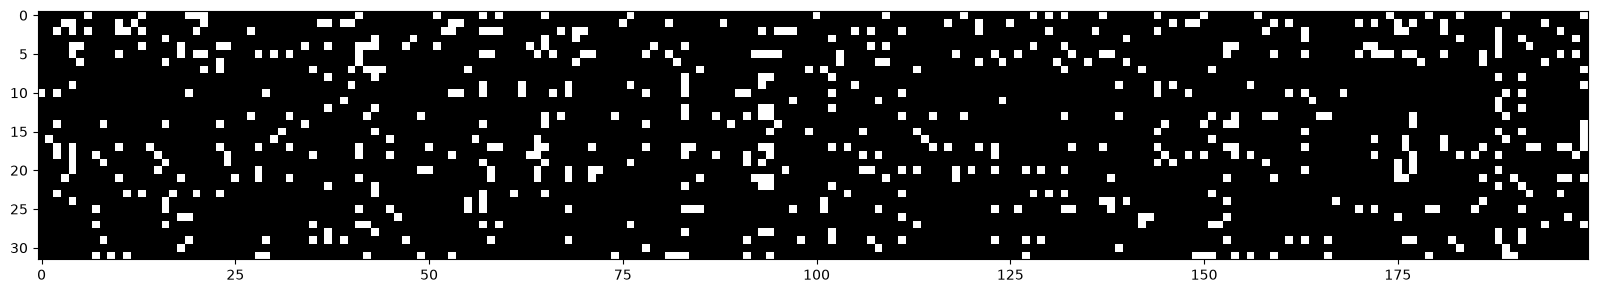

In [23]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

(array([621., 293., 228., 174., 140., 128., 103., 110., 107.,  84., 112.,
         79.,  75.,  77.,  78.,  71.,  67.,  73.,  62.,  44.,  59.,  62.,
         56.,  59.,  59.,  68.,  73.,  53.,  83.,  88.,  78.,  68.,  66.,
         71.,  81.,  87.,  78.,  69.,  69., 120.,  84.,  88., 123., 111.,
        146., 130., 183., 242., 349., 771.]),
 array([-9.99984145e-01, -9.59984832e-01, -9.19985518e-01, -8.79986205e-01,
        -8.39986892e-01, -7.99987578e-01, -7.59988265e-01, -7.19988952e-01,
        -6.79989638e-01, -6.39990325e-01, -5.99991012e-01, -5.59991698e-01,
        -5.19992385e-01, -4.79993072e-01, -4.39993758e-01, -3.99994445e-01,
        -3.59995131e-01, -3.19995818e-01, -2.79996505e-01, -2.39997191e-01,
        -1.99997878e-01, -1.59998565e-01, -1.19999251e-01, -7.99999380e-02,
        -4.00006247e-02, -1.31130219e-06,  3.99980021e-02,  7.99973154e-02,
         1.19996629e-01,  1.59995942e-01,  1.99995255e-01,  2.39994569e-01,
         2.79993882e-01,  3.19993196e-01,  3.59992

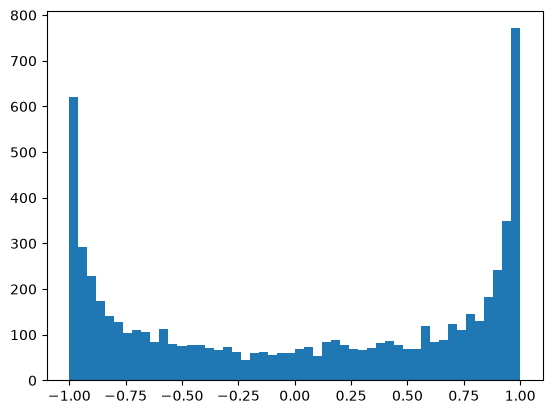

In [24]:
plt.hist(h.view(-1).tolist(), 50)

(array([  2.,   3.,   1.,   2.,   2.,   1.,   6.,   8.,  13.,  27.,  36.,
         35.,  59.,  87., 120., 112., 136., 207., 222., 254., 277., 318.,
        361., 352., 321., 406., 389., 356., 335., 305., 263., 273., 243.,
        190., 124., 136., 122.,  94.,  52.,  33.,  28.,  25.,  18.,  16.,
          9.,   6.,   2.,  10.,   2.,   1.]),
 array([-5.87298298, -5.6396109 , -5.40623882, -5.17286674, -4.93949467,
        -4.70612259, -4.47275051, -4.23937843, -4.00600636, -3.77263428,
        -3.5392622 , -3.30589012, -3.07251804, -2.83914597, -2.60577389,
        -2.37240181, -2.13902973, -1.90565765, -1.67228558, -1.4389135 ,
        -1.20554142, -0.97216934, -0.73879726, -0.50542519, -0.27205311,
        -0.03868103,  0.19469105,  0.42806313,  0.6614352 ,  0.89480728,
         1.12817936,  1.36155144,  1.59492352,  1.82829559,  2.06166767,
         2.29503975,  2.52841183,  2.76178391,  2.99515598,  3.22852806,
         3.46190014,  3.69527222,  3.92864429,  4.16201637,  4.39538845,
 

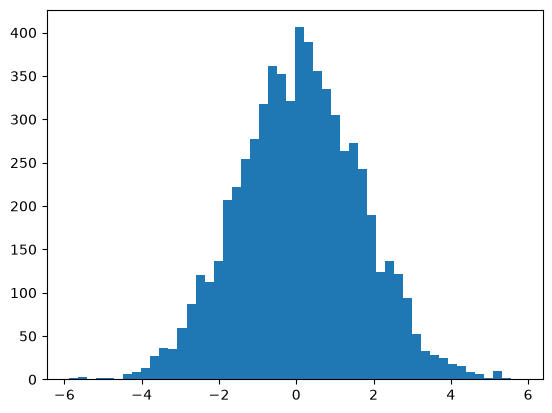

In [25]:
plt.hist(hpreact.view(-1).tolist(), 50)

In [30]:
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [37]:
@torch.no_grad()
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.8742724657058716
val 2.0769193172454834


In [38]:
g = torch.Generator().manual_seed(2147483647)

for i in range(30):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor(context)]
        embcat = emb.view(-1)
        hpreact = embcat @ W1 + b1
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        h = torch.tanh(hpreact)
        logits = h @ W2 + b2
        prob = F.softmax(logits, dim=1)
        ix = torch.multinomial(prob, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        context = context[1:] + [ix]
        if ix == 0:
            break
    print(''.join(out))

gavindile.
hale.
ulurtsalan.
çınalp.
içiç.
başal.
yavulcin.
aykan.
sevende.
zeymani.
donurbaykarık.
fıi.
uğa.
toysime.
gülun.
bedim.
gençağab.
onçun.
han.
şahire.
san.
bulday.
özdeğesliyvet.
zümrülütanu.
gülseruz.
evfihrin.
der.
huder.
enel.
ilfikri.
